<a href="https://colab.research.google.com/github/krishbisen/ML-DL/blob/main/home_credit_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Home Credit Default Risk - final notebook (GCI Global 2026)

Builds `output/submission.csv` and the ZIP needed for Honors.

**What this notebook does (all inside the competition rules: only `train.csv` / `test.csv`, no external data, no hand-labelling, fixed seeds):**

1. Tutorial-style baseline (5 features, Random Forest) so you can see the improvement.
2. Cleaning + feature engineering (ratios, `EXT_SOURCE` combos, missing counts, frequency encoding).
3. **A/B test**: model-based imputation of the missing `EXT_SOURCE_*` values (uses features only, never the target). It is kept only if cross-validation says it helps.
4. Three different gradient-boosting models, each with 5-fold CV, early stopping and seed averaging: **LightGBM, XGBoost, CatBoost**.
5. Blending (rank average / weighted / logistic stack). The best one by out-of-fold AUC is written to the submission.
6. Format checks, then the ZIP of this notebook (Section 6.3 of the tutorial).

Run all cells from top to bottom. Set `FAST = True` first if you only want a quick smoke test.

## 1. Setup

In [2]:
# ---- settings you may change -------------------------------------------------
FAST = False          # True = tiny/quick run just to check that everything works
USE_GPU = False       # True only if the Colab runtime has a GPU (XGBoost + CatBoost use it)
SEED = 42
NOTEBOOK_FILENAME = "home_credit_final.ipynb"      # name of THIS notebook file (used for the ZIP at the end)
PROJECT_DIR = "/content/drive/MyDrive/00_GCIGlobal/Competition"   # folder that contains input/
# ------------------------------------------------------------------------------

import os, sys, time, random, warnings, subprocess, itertools
from pathlib import Path
warnings.filterwarnings("ignore")

try:
    import catboost                      # not preinstalled on Colab
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "catboost"])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
import xgboost as xgb
from catboost import CatBoostClassifier
from scipy.stats import rankdata
from scipy.special import logit
from sklearn.model_selection import StratifiedKFold, cross_val_predict, train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

# Google Drive (only when running on Colab)
try:
    from google.colab import drive
    drive.mount("/content/drive")
    os.chdir(PROJECT_DIR)
except ImportError:
    pass

# Reproducibility: fixed seeds everywhere
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED); np.random.seed(SEED)

current_dir = Path(os.getcwd())
print("working folder:", current_dir)
# print("lightgbm", lgb.__version__, "| xgboost", xgb.__version__, "| catboost", catboost.__version__,
#       "| pandas", pd.__version__, "| numpy", np.__version__)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
working folder: /content/drive/MyDrive/00_GCIGlobal/Competition


## 2. Load the data

In [3]:
train_file = current_dir / "input" / "train.csv"
test_file = current_dir / "input" / "test.csv"
sample_sub_file = current_dir / "input" / "sample_submission.csv"
assert train_file.exists() and test_file.exists() and sample_sub_file.exists(), \
    "Some files are missing - check PROJECT_DIR / the input folder"

train = pd.read_csv(train_file)
test = pd.read_csv(test_file)
sample_sub = pd.read_csv(sample_sub_file)

ID_COL = "SK_ID_CURR"
y = train["TARGET"].values
feat_cols = [c for c in train.columns if c not in ("TARGET", ID_COL)]
print(f"train {train.shape} | test {test.shape} | features {len(feat_cols)} | default rate {y.mean():.4f}")

# train + test stacked so every encoding is built on the same schema (no target involved -> no leakage)
raw = pd.concat([train[feat_cols], test[feat_cols]], keys=["train", "test"])

train (171202, 34) | test (61500, 33) | features 32 | default rate 0.0807


## 3. Baseline = the tutorial model (5 features, Random Forest, 70/30 hold-out)
Only to measure the improvement. This reproduces the tutorial's recipe.

In [4]:
b_feats = ["NAME_CONTRACT_TYPE", "AMT_INCOME_TOTAL", "EXT_SOURCE_2", "OWN_CAR_AGE", "ORGANIZATION_TYPE"]
b = train[b_feats].copy()
b["NAME_CONTRACT_TYPE"] = b["NAME_CONTRACT_TYPE"].map({"Cash loans": 0, "Revolving loans": 1})
b["ORGANIZATION_TYPE"] = b["ORGANIZATION_TYPE"].map(b["ORGANIZATION_TYPE"].value_counts())
b["EXT_SOURCE_2"] = b["EXT_SOURCE_2"].fillna(b["EXT_SOURCE_2"].mean())
b.loc[b["OWN_CAR_AGE"] >= 60, "OWN_CAR_AGE"] = np.nan
b["OWN_CAR_AGE"] = b["OWN_CAR_AGE"] // 10
b = pd.concat([b.drop(columns="OWN_CAR_AGE"), pd.get_dummies(b["OWN_CAR_AGE"]).add_prefix("OWN_CAR_AGE_")], axis=1)
b.columns = b.columns.astype(str)

Xb = StandardScaler().fit_transform(b.values.astype(float))
Xb_tr, Xb_va, yb_tr, yb_va = train_test_split(Xb, y, test_size=0.3, stratify=y, random_state=0)
rf = RandomForestClassifier(random_state=0, max_depth=10, n_jobs=-1).fit(Xb_tr, yb_tr)
baseline_auc = roc_auc_score(yb_va, rf.predict_proba(Xb_va)[:, 1])
print(f"Tutorial-style baseline  validation AUC = {baseline_auc:.4f}")

Tutorial-style baseline  validation AUC = 0.6688


## 4. Cleaning and feature engineering
Fixes found in the EDA: `XNA` means missing, `DAYS_EMPLOYED == 365243` is a placeholder, car age >= 60 is an outlier.

In [5]:
def clean(df):
    df = df.copy()
    for c in df.select_dtypes(include=["object", "string"]).columns:
        df[c] = df[c].replace("XNA", np.nan)                       # 1) XNA = missing marker
    if "DAYS_EMPLOYED" in df.columns:
        df["DAYS_EMPLOYED"] = df["DAYS_EMPLOYED"].replace(365243, np.nan)   # 2) placeholder, not a real value
    if "OWN_CAR_AGE" in df.columns:
        df.loc[df["OWN_CAR_AGE"] >= 60, "OWN_CAR_AGE"] = np.nan    # 3) outlier
    return df

clean_df = clean(raw)
EXT_COLS = [c for c in ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"] if c in clean_df.columns]
print("missing cells after cleaning:", int(clean_df.isna().sum().sum()))

missing cells after cleaning: 602463


In [6]:
def safe_div(a, b):
    return a / b.replace(0, np.nan)

def engineer(df):
    """Ratios, time features and EXT_SOURCE combinations. Everything is guarded by `has`."""
    has = lambda *cols: all(c in df.columns for c in cols)
    new = {}
    if has("AMT_CREDIT", "AMT_INCOME_TOTAL"):  new["CREDIT_TO_INCOME"] = safe_div(df["AMT_CREDIT"], df["AMT_INCOME_TOTAL"])
    if has("AMT_ANNUITY", "AMT_INCOME_TOTAL"): new["ANNUITY_TO_INCOME"] = safe_div(df["AMT_ANNUITY"], df["AMT_INCOME_TOTAL"])
    if has("AMT_ANNUITY", "AMT_CREDIT"):       new["ANNUITY_TO_CREDIT"] = safe_div(df["AMT_ANNUITY"], df["AMT_CREDIT"])
    if has("AMT_GOODS_PRICE", "AMT_CREDIT"):   new["GOODS_TO_CREDIT"] = safe_div(df["AMT_GOODS_PRICE"], df["AMT_CREDIT"])
    if has("AMT_INCOME_TOTAL", "CNT_FAM_MEMBERS"): new["INCOME_PER_PERSON"] = safe_div(df["AMT_INCOME_TOTAL"], df["CNT_FAM_MEMBERS"])
    if has("AMT_INCOME_TOTAL"):                new["LOG_INCOME"] = np.log1p(df["AMT_INCOME_TOTAL"])
    if has("DAYS_BIRTH"):                      new["AGE_YEARS"] = -df["DAYS_BIRTH"] / 365.25
    if has("DAYS_EMPLOYED", "DAYS_BIRTH"):     new["EMPLOYED_TO_AGE"] = safe_div(df["DAYS_EMPLOYED"], df["DAYS_BIRTH"])
    if has("DAYS_EMPLOYED"):                   new["YEARS_EMPLOYED"] = -df["DAYS_EMPLOYED"] / 365.25
    if len(EXT_COLS) >= 2:
        new["EXT_MEAN"] = df[EXT_COLS].mean(axis=1)
        new["EXT_MIN"] = df[EXT_COLS].min(axis=1)
        new["EXT_MAX"] = df[EXT_COLS].max(axis=1)
        new["EXT_STD"] = df[EXT_COLS].std(axis=1)
        new["EXT_PROD"] = df[EXT_COLS].prod(axis=1, skipna=True)
    if has("EXT_SOURCE_2", "DAYS_BIRTH"):      new["EXT2_X_AGE"] = df["EXT_SOURCE_2"] * (-df["DAYS_BIRTH"] / 365.25)
    return pd.DataFrame(new, index=df.index).replace([np.inf, -np.inf], np.nan)

### 4.1 Model-based imputation of `EXT_SOURCE_*` (A/B tested later)
The `EXT_SOURCE` scores are the strongest columns but are often missing. For each one, a small LightGBM regressor is trained on the rows where it is known (using the other columns, **never the target**) and used only to fill the rows where it is missing.

In [7]:
def impute_ext(df, seed=SEED):
    out = df.copy()
    H = df.copy()
    for c in H.select_dtypes(include=["object", "string"]).columns:
        H[c] = H[c].astype("category")
    for col in EXT_COLS:
        others = [c for c in H.columns if c != col]
        known = H[col].notna()
        if known.sum() < 100 or known.all():
            continue
        m = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05, num_leaves=31, min_child_samples=50,
                              subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
                              random_state=seed, verbose=-1)
        m.fit(H.loc[known, others], H.loc[known, col])
        out.loc[~known, col] = np.clip(m.predict(H.loc[~known, others]), 0, 1)
    return out


def build_matrix(impute):
    df = clean_df.copy()
    n_missing = df.isna().sum(axis=1)                               # informative on its own
    ext_flags = {f"{c}_WAS_NA": df[c].isna().astype(int) for c in EXT_COLS}
    if impute:
        df = impute_ext(df)
    new_df = engineer(df)
    new_df["N_MISSING"] = n_missing
    if impute:
        for k, v in ext_flags.items():
            new_df[k] = v
    new_cols = list(new_df.columns)
    df = pd.concat([df, new_df], axis=1)

    # encoding: frequency column + native category dtype for every text column
    cats = df.select_dtypes(include=["object", "string"]).columns.tolist()
    for c in cats:
        df[c + "_FREQ"] = df[c].map(df[c].value_counts()).astype(float)
        df[c] = df[c].astype("category")
    return df.loc["train"].reset_index(drop=True), df.loc["test"].reset_index(drop=True), cats, new_cols

## 5. Models
All models use stratified 5-fold CV with early stopping, return **out-of-fold (OOF) predictions** (an honest score on every training row) and averaged test predictions.
LightGBM parameters are the best ones found by your earlier random search.

In [8]:
N_SPLITS = 3 if FAST else 5
LGB_SEEDS = [11] if FAST else [11, 22, 33]
XGB_SEEDS = [42] if FAST else [42, 43]
CAT_SEEDS = [42] if FAST else [42]
N_EST = 300 if FAST else 4000
CAT_ITER = 200 if FAST else 2000

lgb_params = dict(learning_rate=0.03, num_leaves=63, max_depth=6, min_child_samples=50,
                  subsample=0.932, subsample_freq=1, colsample_bytree=0.4927,
                  reg_alpha=0.0, reg_lambda=5.0)
xgb_params = dict(learning_rate=0.03, max_depth=5, min_child_weight=20, subsample=0.9,
                  colsample_bytree=0.5, reg_lambda=5.0)
cat_params = dict(learning_rate=0.06, depth=6, l2_leaf_reg=5)


def cv_lgbm(X, y, X_test, seed, n_splits=N_SPLITS, params=lgb_params, n_estimators=N_EST):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    oof, pred = np.zeros(len(X)), np.zeros(len(X_test))
    for tr, va in skf.split(X, y):
        m = lgb.LGBMClassifier(**params, n_estimators=n_estimators, random_state=seed, verbose=-1)
        m.fit(X.iloc[tr], y[tr], eval_set=[(X.iloc[va], y[va])], eval_metric="auc",
              callbacks=[lgb.early_stopping(100, verbose=False)])
        oof[va] = m.predict_proba(X.iloc[va])[:, 1]
        pred += m.predict_proba(X_test)[:, 1] / n_splits
    return oof, pred


def cv_xgb(X, y, X_test, seed, n_splits=N_SPLITS):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    oof, pred = np.zeros(len(X)), np.zeros(len(X_test))
    for tr, va in skf.split(X, y):
        m = xgb.XGBClassifier(**xgb_params, n_estimators=N_EST, random_state=seed, tree_method="hist",
                              enable_categorical=True, eval_metric="auc", early_stopping_rounds=100,
                              n_jobs=-1, device="cuda" if USE_GPU else "cpu")
        m.fit(X.iloc[tr], y[tr], eval_set=[(X.iloc[va], y[va])], verbose=False)
        oof[va] = m.predict_proba(X.iloc[va])[:, 1]
        pred += m.predict_proba(X_test)[:, 1] / n_splits
    return oof, pred


def cat_frame(X, cats):
    """CatBoost wants plain strings for categorical columns."""
    Z = X.copy()
    for c in cats:
        Z[c] = Z[c].astype("object").fillna("NA").astype(str)
    return Z


def cv_cat(X, y, X_test, seed, cats, n_splits=N_SPLITS):
    Z, Zt = cat_frame(X, cats), cat_frame(X_test, cats)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    oof, pred = np.zeros(len(X)), np.zeros(len(X_test))
    for tr, va in skf.split(Z, y):
        m = CatBoostClassifier(**cat_params, iterations=CAT_ITER, eval_metric="AUC", random_seed=seed,
                               od_type="Iter", od_wait=100, verbose=0, allow_writing_files=False,
                               cat_features=cats, thread_count=-1, task_type="GPU" if USE_GPU else "CPU")
        m.fit(Z.iloc[tr], y[tr], eval_set=(Z.iloc[va], y[va]), use_best_model=True)
        oof[va] = m.predict_proba(Z.iloc[va])[:, 1]
        pred += m.predict_proba(Zt)[:, 1] / n_splits
    return oof, pred

### 5.1 A/B test: is `EXT_SOURCE` imputation worth it?
Same LightGBM, same 3-fold split, with and without the imputation. It is used only if the gain is at least 0.0005 (the noise level you found earlier). The decision is made by code from CV scores, so it is reproducible.

In [9]:
t0 = time.time()
X_a, Xt_a, cats_a, new_a = build_matrix(impute=False)
X_b, Xt_b, cats_b, new_b = build_matrix(impute=True)

quick = dict(lgb_params, learning_rate=0.08)
oof_a, _ = cv_lgbm(X_a, y, Xt_a.iloc[:5], seed=1, n_splits=3, params=quick)
oof_b, _ = cv_lgbm(X_b, y, Xt_b.iloc[:5], seed=1, n_splits=3, params=quick)
auc_a, auc_b = roc_auc_score(y, oof_a), roc_auc_score(y, oof_b)
print(f"without imputation: {auc_a:.4f} | with EXT imputation: {auc_b:.4f} | gain {auc_b - auc_a:+.4f}")

USE_IMPUTED = (auc_b - auc_a) >= 0.0005
X, X_test, cat_cols, new_cols = (X_b, Xt_b, cats_b, new_b) if USE_IMPUTED else (X_a, Xt_a, cats_a, new_a)
print("using imputed EXT_SOURCE:", USE_IMPUTED, "| matrix:", X.shape, X_test.shape, f"({time.time()-t0:.0f}s)")

without imputation: 0.7564 | with EXT imputation: 0.7568 | gain +0.0004
using imputed EXT_SOURCE: False | matrix: (171202, 56) (61500, 56) (96s)


### 5.2 Train LightGBM, XGBoost and CatBoost

In [10]:
results = {}      # model name -> (oof, test_pred)

t0 = time.time()
o, p = zip(*[cv_lgbm(X, y, X_test, seed=s) for s in LGB_SEEDS])
results["LightGBM"] = (np.mean(o, axis=0), np.mean(p, axis=0))
print(f"LightGBM   OOF AUC = {roc_auc_score(y, results['LightGBM'][0]):.4f}  ({time.time()-t0:.0f}s)")

t0 = time.time()
o, p = zip(*[cv_xgb(X, y, X_test, seed=s) for s in XGB_SEEDS])
results["XGBoost"] = (np.mean(o, axis=0), np.mean(p, axis=0))
print(f"XGBoost    OOF AUC = {roc_auc_score(y, results['XGBoost'][0]):.4f}  ({time.time()-t0:.0f}s)")

t0 = time.time()
o, p = zip(*[cv_cat(X, y, X_test, seed=s, cats=cat_cols) for s in CAT_SEEDS])
results["CatBoost"] = (np.mean(o, axis=0), np.mean(p, axis=0))
print(f"CatBoost   OOF AUC = {roc_auc_score(y, results['CatBoost'][0]):.4f}  ({time.time()-t0:.0f}s)")

LightGBM   OOF AUC = 0.7615  (441s)
XGBoost    OOF AUC = 0.7606  (820s)
CatBoost   OOF AUC = 0.7599  (1116s)


## 6. Blending
Candidates: equal **rank average** (safe for AUC, only the ordering matters), a **weighted** rank average (weights searched on a 0.1 grid), and a **logistic-regression stack**. The one with the highest OOF AUC is used.
The stack is scored with its own cross-validation, so its number is honest.

In [11]:
names = list(results)
oofs = {n: results[n][0] for n in names}
tests = {n: results[n][1] for n in names}
rk = lambda a: rankdata(a) / len(a)

candidates = {n: (oofs[n], tests[n]) for n in names}                # single models

# 1) equal rank average
candidates["Rank average"] = (np.mean([rk(oofs[n]) for n in names], axis=0),
                              np.mean([rk(tests[n]) for n in names], axis=0))

# 2) weighted rank average (grid, weights sum to 1)
best_w, best_auc = None, -1
steps = np.arange(0, 1.01, 0.1)
for w in itertools.product(steps, repeat=len(names)):
    if abs(sum(w) - 1) > 1e-9:
        continue
    a = roc_auc_score(y, sum(wi * rk(oofs[n]) for wi, n in zip(w, names)))
    if a > best_auc:
        best_auc, best_w = a, w
candidates["Weighted rank average"] = (sum(wi * rk(oofs[n]) for wi, n in zip(best_w, names)),
                                       sum(wi * rk(tests[n]) for wi, n in zip(best_w, names)))
print("best weights:", dict(zip(names, np.round(best_w, 2))))

# 3) logistic-regression stack on logits of the OOF predictions
clip = lambda a: logit(np.clip(a, 1e-6, 1 - 1e-6))
Z_oof = np.column_stack([clip(oofs[n]) for n in names])
Z_te = np.column_stack([clip(tests[n]) for n in names])
meta = LogisticRegression(C=1.0, max_iter=1000)
oof_stack = cross_val_predict(meta, Z_oof, y, cv=StratifiedKFold(5, shuffle=True, random_state=SEED),
                              method="predict_proba")[:, 1]
candidates["Logistic stack"] = (oof_stack, meta.fit(Z_oof, y).predict_proba(Z_te)[:, 1])

scores = {n: roc_auc_score(y, o) for n, (o, _) in candidates.items()}
for n, s in sorted(scores.items(), key=lambda kv: -kv[1]):
    print(f"{n:<24} OOF AUC = {s:.4f}")

best_name = max(scores, key=scores.get)
final_oof, pred = candidates[best_name]
print(f"\n>>> selected: {best_name}  (OOF AUC = {scores[best_name]:.4f})")

best weights: {'LightGBM': np.float64(0.5), 'XGBoost': np.float64(0.1), 'CatBoost': np.float64(0.4)}
Weighted rank average    OOF AUC = 0.7626
Logistic stack           OOF AUC = 0.7626
Rank average             OOF AUC = 0.7626
LightGBM                 OOF AUC = 0.7615
XGBoost                  OOF AUC = 0.7606
CatBoost                 OOF AUC = 0.7599

>>> selected: Weighted rank average  (OOF AUC = 0.7626)


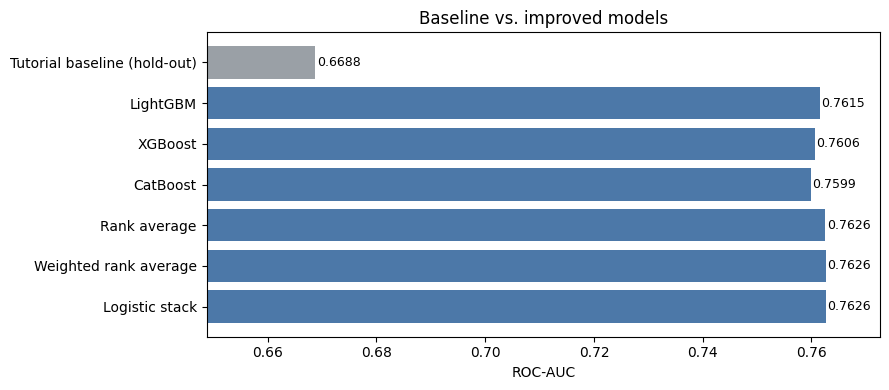

Improvement over the tutorial baseline: +0.0938 AUC


In [12]:
fig, ax = plt.subplots(figsize=(9, 4))
labels = ["Tutorial baseline (hold-out)"] + list(scores)
vals = [baseline_auc] + list(scores.values())
bars = ax.barh(labels, vals, color=["#9aa0a6"] + ["#4c78a8"] * len(scores))
ax.set_xlim(min(vals) - 0.02, max(vals) + 0.01)
for b_, v in zip(bars, vals):
    ax.text(v + 0.0003, b_.get_y() + b_.get_height() / 2, f"{v:.4f}", va="center", fontsize=9)
ax.invert_yaxis(); ax.set_xlabel("ROC-AUC"); ax.set_title("Baseline vs. improved models")
plt.tight_layout(); plt.show()
print(f"Improvement over the tutorial baseline: {scores[best_name] - baseline_auc:+.4f} AUC")

## 7. Create `output/submission.csv`
Same format as the tutorial (Section 6.2): `SK_ID_CURR`, `TARGET`. Checks make sure the file cannot be rejected for format reasons.

In [13]:
# make sure the predictions line up with the ids of sample_submission
id_to_pred = dict(zip(test[ID_COL].values, pred))
sample_sub["TARGET"] = sample_sub[ID_COL].map(id_to_pred)

assert sample_sub["TARGET"].notna().all(), "some ids in sample_submission are missing from test"
assert len(sample_sub) == len(test), "row count differs from test"
assert list(sample_sub.columns) == [ID_COL, "TARGET"], "columns must be SK_ID_CURR, TARGET"
assert sample_sub["TARGET"].between(0, 1).all(), "predictions must be between 0 and 1"
assert sample_sub[ID_COL].is_unique

output_dir = current_dir / "output"
os.makedirs(output_dir, exist_ok=True)
output_file = output_dir / "submission_final.csv"
sample_sub.to_csv(output_file, index=False)
print("saved:", output_file, sample_sub.shape)
sample_sub.head()

saved: /content/drive/MyDrive/00_GCIGlobal/Competition/output/submission_final.csv (61500, 2)


,SK_ID_CURR,TARGET
0,171202,0.229447
1,171203,0.890816
2,171204,0.832717
3,171205,0.717574
4,171206,0.882530


## 8. Save this notebook as a ZIP (required for Honors / Outstanding Student)
Save the notebook first (Ctrl+S / Cmd+S) so the ZIP contains the latest version, then run this cell and upload the ZIP together with `submission.csv`.

In [14]:
import zipfile

zip_filename = NOTEBOOK_FILENAME.replace(".ipynb", ".zip")
notebook_path = current_dir / NOTEBOOK_FILENAME
zip_output_path = current_dir / zip_filename

if notebook_path.exists():
    with zipfile.ZipFile(zip_output_path, "w", zipfile.ZIP_DEFLATED) as zipf:
        zipf.write(notebook_path, arcname=NOTEBOOK_FILENAME)
    print(f"Successfully created: {zip_output_path}")
else:
    print(f"Error: could not find '{NOTEBOOK_FILENAME}' in {current_dir}.")
    print("Check that NOTEBOOK_FILENAME (first cell) matches the real file name, and save the notebook first.")

Error: could not find 'home_credit_final.ipynb' in /content/drive/MyDrive/00_GCIGlobal/Competition.
Check that NOTEBOOK_FILENAME (first cell) matches the real file name, and save the notebook first.
